<a href="https://colab.research.google.com/github/ahsamashir-bit/AI-Study-Assistant-/blob/main/gym_exercise_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import pandas as pd

df = pd.read_csv('/content/cleaned_workouts.csv')
display(df.head())

,title,start_time,end_time,exercise_title,superset_id,set_index,set_type,weight_kg,reps,rpe
0,Legs,"13 May 2026, 18:46","13 May 2026, 19:04",Leg Extension (Machine),0.0,0,failure,80.0,33,10.0
1,Legs,"13 May 2026, 18:46","13 May 2026, 19:04",Leg Press (Machine),0.0,0,failure,175.0,15,10.0
2,Legs,"13 May 2026, 18:46","13 May 2026, 19:04",Calf Press (Machine),NaN,0,failure,195.0,37,10.0
3,Arms,"5 May 2026, 18:54","5 May 2026, 19:16",Lateral Raise (Dumbbell),NaN,0,failure,30.0,10,10.0
4,Arms,"5 May 2026, 18:54","5 May 2026, 19:16",Rear Delt Reverse Fly (Machine),NaN,0,failure,80.0,8,10.0


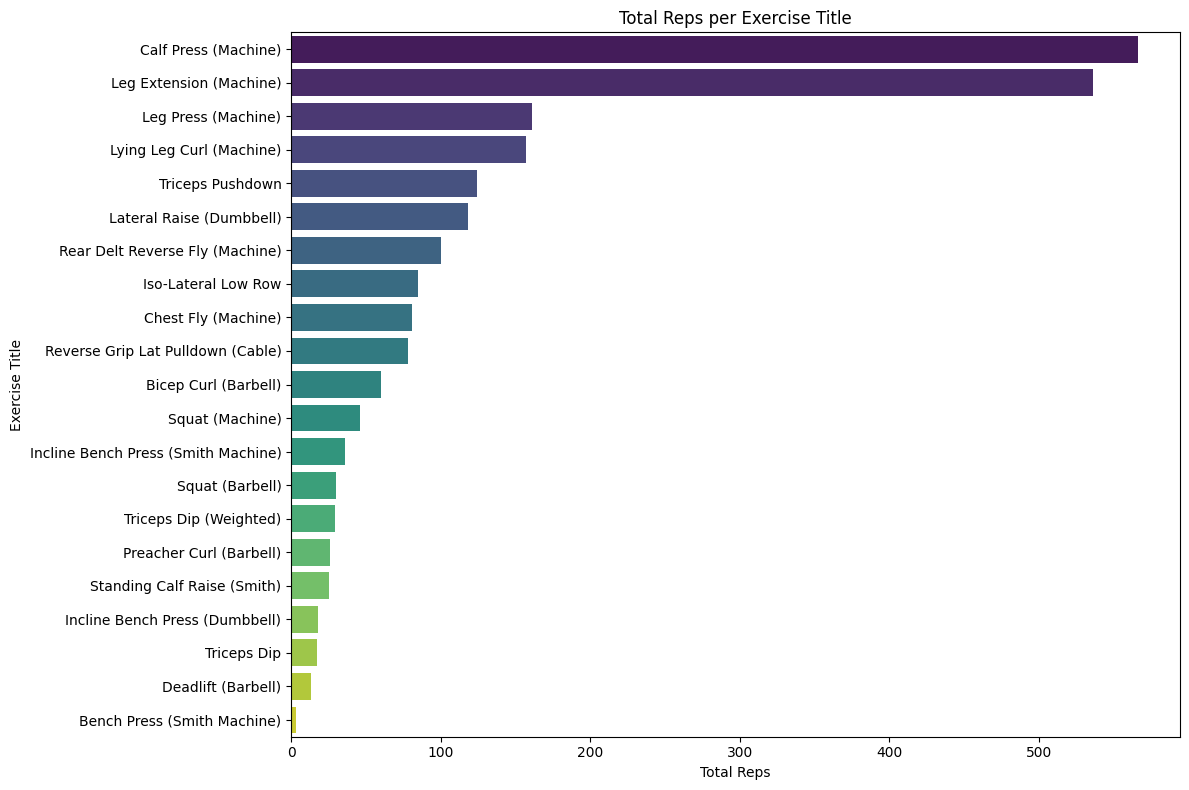

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total reps per exercise title
total_reps_per_exercise = df.groupby('exercise_title')['reps'].sum().reset_index()

# Sort for better visualization (optional)
total_reps_per_exercise = total_reps_per_exercise.sort_values(by='reps', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='reps', y='exercise_title', data=total_reps_per_exercise, palette='viridis', hue='exercise_title', legend=False)
plt.title('Total Reps per Exercise Title')
plt.xlabel('Total Reps')
plt.ylabel('Exercise Title')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the average RPE for each exercise title
average_rpe_per_exercise = df.groupby('exercise_title')['rpe'].mean().reset_index()

# Display the result, sorted for better readability
display(average_rpe_per_exercise.sort_values(by='rpe', ascending=False))

,exercise_title,rpe
0,Bench Press (Smith Machine),10.000000
2,Calf Press (Machine),10.000000
3,Chest Fly (Machine),10.000000
4,Deadlift (Barbell),10.000000
5,Incline Bench Press (Dumbbell),10.000000
17,Standing Calf Raise (Smith),10.000000
6,Incline Bench Press (Smith Machine),10.000000
7,Iso-Lateral Low Row,10.000000
8,Lateral Raise (Dumbbell),10.000000
10,Leg Press (Machine),10.000000


In [ ]:
# Calculate 'volume' as weight_kg * reps
df['volume'] = df['weight_kg'] * df['reps']

# Calculate the total volume for each exercise title
total_volume_per_exercise = df.groupby('exercise_title')['volume'].sum().reset_index()

# Display the result, sorted for better readability
display(total_volume_per_exercise.sort_values(by='volume', ascending=False))

,exercise_title,volume
2,Calf Press (Machine),79125.0
9,Leg Extension (Machine),42880.0
10,Leg Press (Machine),23467.5
11,Lying Leg Curl (Machine),11325.0
20,Triceps Pushdown,7575.0
7,Iso-Lateral Low Row,6830.0
13,Rear Delt Reverse Fly (Machine),6635.0
14,Reverse Grip Lat Pulldown (Cable),5600.0
3,Chest Fly (Machine),5575.0
16,Squat (Machine),4760.0


In [ ]:
# Filter the DataFrame for 'Triceps Dip' entries
triceps_dip_data = df[df['exercise_title'] == 'Triceps Dip']

# Display relevant columns to understand the volume calculation
print("Data for 'Triceps Dip':")
display(triceps_dip_data[['exercise_title', 'weight_kg', 'reps', 'volume']])

# Check for NaN or zero values specifically
print("\nSummary of 'weight_kg' and 'reps' for 'Triceps Dip':")
print(triceps_dip_data[['weight_kg', 'reps']].describe())

Data for 'Triceps Dip':


,exercise_title,weight_kg,reps,volume
122,Triceps Dip,NaN,5,NaN
139,Triceps Dip,NaN,5,NaN
156,Triceps Dip,NaN,3,NaN
173,Triceps Dip,NaN,4,NaN



Summary of 'weight_kg' and 'reps' for 'Triceps Dip':
       weight_kg      reps
count        0.0  4.000000
mean         NaN  4.250000
std          NaN  0.957427
min          NaN  3.000000
25%          NaN  3.750000
50%          NaN  4.500000
75%          NaN  5.000000
max          NaN  5.000000


In [ ]:
# Define a bodyweight estimate for dips where weight_kg is NaN
bodyweight_estimate = 80  # in kg

# Fill NaN weight_kg values for 'Triceps Dip' with the bodyweight estimate
df.loc[(df['exercise_title'] == 'Triceps Dip') & (df['weight_kg'].isna()), 'weight_kg'] = bodyweight_estimate

# Recalculate the 'volume' column for 'Triceps Dip' entries
df.loc[df['exercise_title'] == 'Triceps Dip', 'volume'] = df['weight_kg'] * df['reps']

# Calculate the updated total volume for 'Triceps Dip'
updated_triceps_dip_volume = df[df['exercise_title'] == 'Triceps Dip']['volume'].sum()

print(f"Updated total volume for 'Triceps Dip': {updated_triceps_dip_volume:.2f}")

# Recalculate total volume for all exercises and display top entries to see the change
total_volume_per_exercise_updated = df.groupby('exercise_title')['volume'].sum().reset_index()
display(total_volume_per_exercise_updated.sort_values(by='volume', ascending=False).head())

Updated total volume for 'Triceps Dip': 1360.00


,exercise_title,volume
2,Calf Press (Machine),79125.0
9,Leg Extension (Machine),42880.0
10,Leg Press (Machine),23467.5
11,Lying Leg Curl (Machine),11325.0
20,Triceps Pushdown,7575.0


Correlation between Weight (kg) and Reps: 0.50


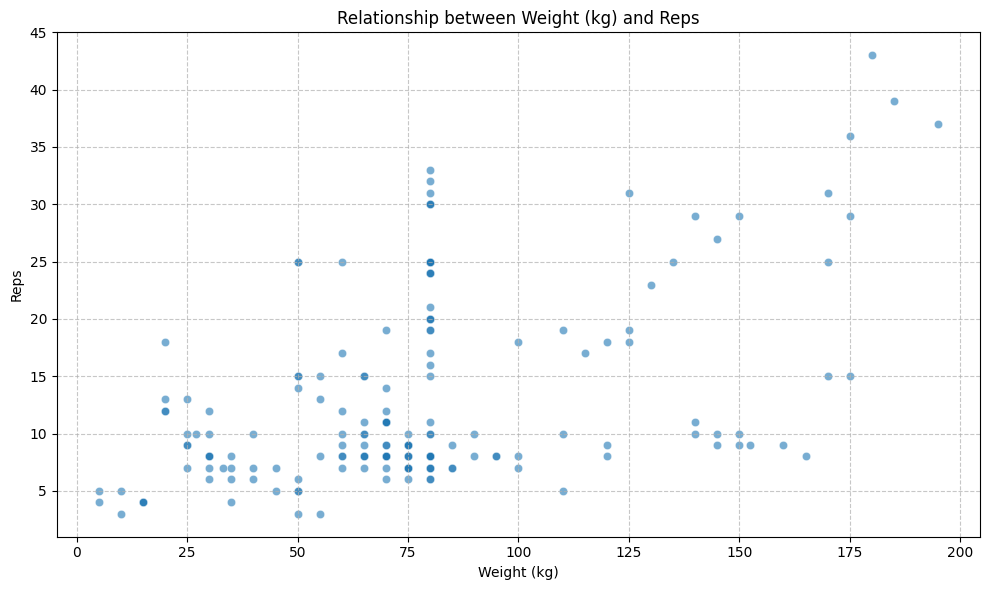

In [ ]:
# Calculate the correlation between 'weight_kg' and 'reps'
correlation = df['weight_kg'].corr(df['reps'])
print(f"Correlation between Weight (kg) and Reps: {correlation:.2f}")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight_kg', y='reps', data=df, alpha=0.6)
plt.title('Relationship between Weight (kg) and Reps')
plt.xlabel('Weight (kg)')
plt.ylabel('Reps')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Group by 'title' and sum the 'reps'
total_reps_per_title = df.groupby('title')['reps'].sum().reset_index()

# Display the result
display(total_reps_per_title.sort_values(by='reps', ascending=False))

,title,reps
9,Legs,647
0,Arms,392
6,Leg day 2 🐯🐅,280
10,Legs again,243
3,Chest and Back,148
5,Chest and Back 🐯🐅,130
13,Legs 🦵🏾🐯🐅,82
12,Legs 🦵🏾 🐯🐅,76
11,Legs and Data analysis for my lifts,69
8,Leg day reflections and the beginning of somet...,62


In [ ]:
# Group by 'title' and 'exercise_title' and calculate the average reps
average_reps_per_exercise_per_title = df.groupby(['title', 'exercise_title'])['reps'].mean().reset_index()

# Display the result, sorted for better readability
display(average_reps_per_exercise_per_title.sort_values(by=['title', 'reps'], ascending=[True, False]))

,title,exercise_title,reps
6,Arms,Triceps Pushdown,11.444444
1,Arms,Lateral Raise (Dumbbell),11.111111
2,Arms,Preacher Curl (Barbell),10.000000
3,Arms,Rear Delt Reverse Fly (Machine),9.111111
0,Arms,Bicep Curl (Barbell),7.500000
...,...,...,...
63,Legs 🦵🏾 🐯🐅,Lying Leg Curl (Machine),8.000000
64,Legs 🦵🏾🐯🐅,Calf Press (Machine),31.000000
65,Legs 🦵🏾🐯🐅,Leg Extension (Machine),24.000000
66,Legs 🦵🏾🐯🐅,Leg Press (Machine),19.000000


In [ ]:
# Calculate the total weight lifted for each workout title
total_weight_per_title = df.groupby('title')['weight_kg'].sum().reset_index()

# Display the result, sorted for better readability
display(total_weight_per_title.sort_values(by='weight_kg', ascending=False))

,title,weight_kg
9,Legs,3807.5
0,Arms,1755.0
5,Chest and Back 🐯🐅,1360.0
6,Leg day 2 🐯🐅,1300.0
10,Legs again,1285.0
3,Chest and Back,1265.0
11,Legs and Data analysis for my lifts,490.0
12,Legs 🦵🏾 🐯🐅,415.0
13,Legs 🦵🏾🐯🐅,410.0
8,Leg day reflections and the beginning of somet...,400.0


In [ ]:
df.describe()

,superset_id,set_index,weight_kg,reps,rpe,volume
count,88.000000,178.0,178.000000,178.000000,178.000000,178.000000
mean,0.022727,0.0,77.654494,12.971910,9.935393,1170.834270
std,0.149887,0.0,39.989052,8.402602,0.466427,1330.555571
min,0.000000,0.0,5.000000,3.000000,6.000000,20.000000
25%,0.000000,0.0,55.000000,7.250000,10.000000,425.000000
50%,0.000000,0.0,75.000000,9.000000,10.000000,675.000000
75%,0.000000,0.0,80.000000,17.000000,10.000000,1487.500000
max,1.000000,0.0,195.000000,43.000000,10.000000,7740.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           178 non-null    object 
 1   start_time      178 non-null    object 
 2   end_time        178 non-null    object 
 3   exercise_title  178 non-null    object 
 4   superset_id     88 non-null     float64
 5   set_index       178 non-null    int64  
 6   set_type        178 non-null    object 
 7   weight_kg       178 non-null    float64
 8   reps            178 non-null    int64  
 9   rpe             178 non-null    float64
 10  volume          178 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 15.4+ KB


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dataset load
df = pd.read_csv("cleaned_workouts.csv")

# Impute missing weight_kg values with the mean of the column
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].mean())

# Features (input)
X = df[['weight_kg', 'reps']]

# Target column
y = df['exercise_title']

# Text ko number me convert karna
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LogisticRegression()

# Training with scaled data
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5277777777777778


### Confusion Matrix

Let's visualize the confusion matrix to see the breakdown of correct and incorrect predictions for each exercise title.

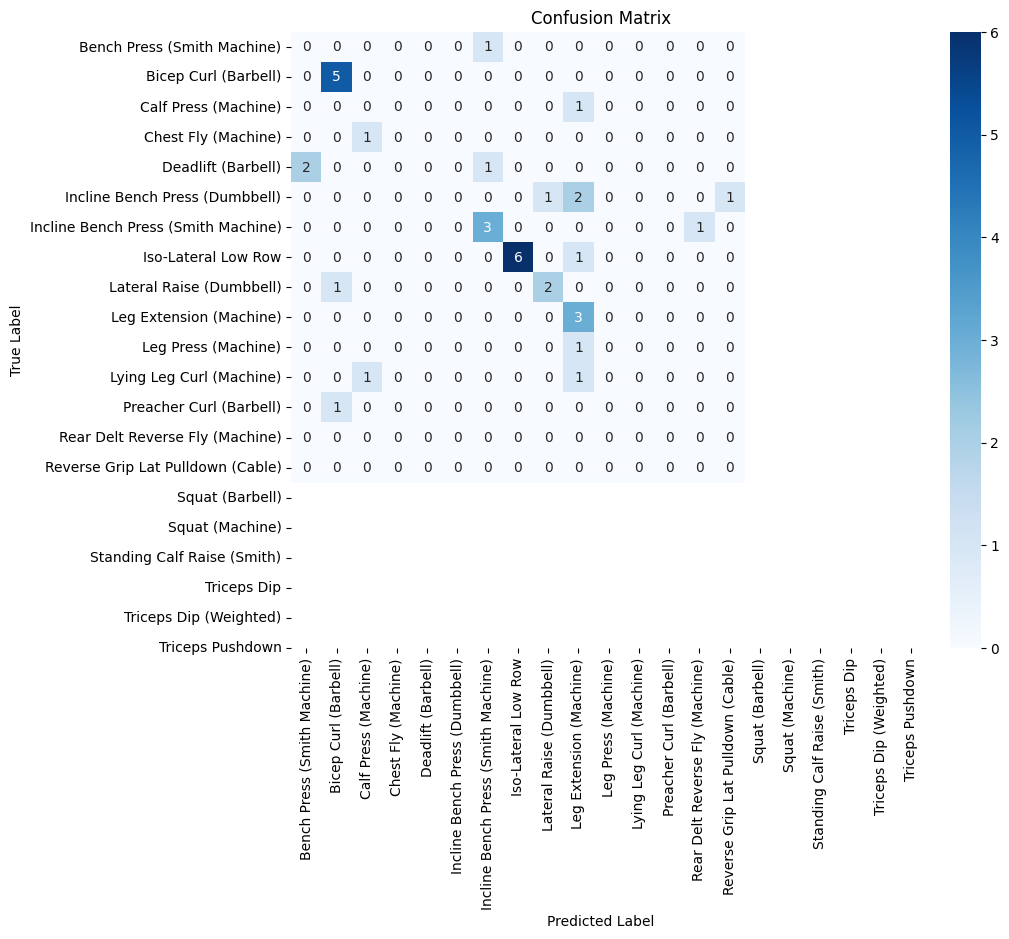

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report

The classification report provides more detailed metrics like precision, recall, and f1-score for each class.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get the unique labels present in y_test
unique_labels_in_test = np.unique(y_test)

# Map these unique labels back to their original names
target_names_for_report = encoder.inverse_transform(unique_labels_in_test)

# Generate the classification report with the correct labels and target names
report = classification_report(y_test, y_pred, labels=unique_labels_in_test, target_names=target_names_for_report)

print("Classification Report:\n", report)

Classification Report:
                                      precision    recall  f1-score   support

               Bicep Curl (Barbell)       0.00      0.00      0.00         1
               Calf Press (Machine)       0.71      1.00      0.83         5
                Chest Fly (Machine)       0.00      0.00      0.00         1
     Incline Bench Press (Dumbbell)       0.00      0.00      0.00         1
Incline Bench Press (Smith Machine)       0.00      0.00      0.00         3
                Iso-Lateral Low Row       0.00      0.00      0.00         4
           Lateral Raise (Dumbbell)       0.60      0.75      0.67         4
            Leg Extension (Machine)       1.00      0.86      0.92         7
                Leg Press (Machine)       0.67      0.67      0.67         3
           Lying Leg Curl (Machine)       0.33      1.00      0.50         3
    Rear Delt Reverse Fly (Machine)       0.00      0.00      0.00         1
  Reverse Grip Lat Pulldown (Cable)       0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Dataset load
df = pd.read_csv("cleaned_workouts.csv")

# Missing values remove
df = df.dropna()

# Features select
X = df[['weight_kg', 'reps']]

# Target column
y = df['exercise_title']

# Convert text into numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7647058823529411

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.50      0.50         2
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         6
           6       1.00      0.75      0.86         4
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       1.00      1.00      1.00         1
          11       0.67      0.67      0.67         3

    accuracy                           0.76        17
   macro avg       0.52      0.49      0.50        17
weighted avg       0.82      0.76      0.79        17


Confusion Matrix:
[[1 0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0 0]
 [0 0 6 0 0 0 0 0]
 [0 0 0 3 0 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 2]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

In [ ]:
model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10])